# Cantaloupe Fruit Maturity Classification via Naive Bayes (Colab reproduction)

**Paper:** M. F. Asy'ari et al., *"Analysis of Cantaloupe Fruit Maturity Based on Fruit Skin Color Using Naive Bayes Classifier"*, J. Phys.: Conf. Ser. **1805** 012028 (2021). [DOI: 10.1088/1742-6596/1805/1/012028](https://doi.org/10.1088/1742-6596/1805/1/012028)

**Author code:** `falachari/tugas-akhir-naive-bayes` @ commit `10620c2a2fa472ef32f8712cc81cc7cbb7a2be1d` (`NaiveBayes.m`, MATLAB R2016a)

**Scope (this notebook):** Reproduce the paper's full classification experiment — 16 training and 14 test cantaloupe-rind JPEGs from the author's repository, the paper's five gray-level histogram features (mean, standard deviation, entropy, skewness, kurtosis), Gaussian Naive Bayes training and testing, and comparison with the published reference accuracies (training 68.75% = 11/16, testing 57.14% = 8/14).

**Execution status:** ADAPTED PYTHON DEMONSTRATION — **AI-assisted translation from MATLAB**; the authors did not provide this Colab implementation. The executed example and listed checks were validated, but untested behavior is not guaranteed. A one-example run is not verification of the paper's dataset-level claims beyond the accuracies computed here.

**Known discrepancy (recorded in the investigation):** the author's script applies a 3×3 median filter to test images while the paper text states 9×9. This notebook follows the script (the actually executed evidence) and adds one clearly labeled 9×9 variant cell.

**日本語:** 本ノートブックは、メロン（カンタループ）果皮画像30枚（学習16枚・テスト14枚）から5種のグレーレベル特徴量（平均・標準偏差・エントロピー・歪度・尖度）を抽出し、ガウシアン・ナイーブベイズで成熟/未成熟分類を再現するものです。著者のMATLABコードをPythonへ翻訳した**AI支援による Adapted Python Demonstration** です。著者によるPython実装は存在しないため、検証済みの範囲（本実行例と比較結果）のみが保証されます。著者スクリプトはテスト画像に3×3メディアンフィルタを用いており、論文記載の9×9とは不一致です（本ノートブックはスクリプトに従い、9×9の比較セルを別途设置）。

## Runtime selection

This method is classical image processing + Gaussian Naive Bayes on 30 small JPEGs. **No GPU is required**: select **Runtime → Change runtime type → CPU** (default). Expected end-to-end time: well under 2 minutes, downloads ≈ 1 MB.

**日本語:** 本手法は古典的な画像処理＋ナイーブベイズであり、GPUは不要です。CPUランタイムでそのまま「ランタイム → すべてのセルを実行」してください。所要は数分以内、ダウンロードは約1MBです。

### Environment and dependency setup

Installs nothing heavy: `numpy`, `scipy`, `scikit-image`, `scikit-learn`, `pillow`, `matplotlib`, `pandas` are all preinstalled in current Colab. This cell verifies versions so the port's numerical behavior is traceable.

**日本語:** 依存パッケージはColabに標準搭載されているもののみ使用します。バージョンを表示して再現性を記録します。

In [ ]:
import sys, hashlib, json, urllib.request, urllib.error, urllib.parse
import numpy as np, scipy, skimage, sklearn, PIL, matplotlib
import pandas as pd

print("python", sys.version.split()[0])
for mod in (np, scipy, skimage, sklearn, PIL, matplotlib, pd):
    print(mod.__name__, mod.__version__)

python 3.13.16
numpy 2.1.3
scipy 1.16.3
skimage 0.25.2
sklearn 1.6.1
PIL 11.3.0
matplotlib 3.10.0
pandas 2.2.3


### Minimal input acquisition (Colab only)

Downloads all 30 rind JPEGs (16 training `data latih copy/l*.jpg`, 14 test `data uji copy/u*.jpg`, ~30 KB each) from the author's pinned commit `10620c2a2fa472ef32f8712cc81cc7cbb7a2be1d` via raw.githubusercontent.com. Integrity is checked against the pinned commit's GitHub tree API blob SHA-1 (git blob hash computed locally, `sha1("blob <size>\\0" + bytes)`), so any changed or truncated file is rejected.

**日本語:** 著者リポジトリの固定コミットから学習16枚・テスト14枚のJPEGを取得し、GitHubツリーAPIのblob SHA-1と照合して改変・破損を検出します。

In [ ]:
REPO = "falachari/tugas-akhir-naive-bayes"
COMMIT = "10620c2a2fa472ef32f8712cc81cc7cbb7a2be1d"
RAW = f"https://raw.githubusercontent.com/{REPO}/{COMMIT}"

# Pinned file list from the author repository tree (30 dataset JPEGs)
paths = [f"data latih copy/l{i}.jpg" for i in range(1, 17)]
paths += [f"data uji copy/u{i}.jpg" for i in range(1, 15)]

def http_get(url, timeout=60):
    req = urllib.request.Request(url, headers={"User-Agent": "colab-repro-notebook"})
    with urllib.request.urlopen(req, timeout=timeout) as r:
        return r.read()

# Blob SHA-1 map from the pinned commit tree (rate-limit friendly: one request)
tree = json.loads(http_get(
    f"https://api.github.com/repos/{REPO}/git/trees/{COMMIT}?recursive=1"))
assert not tree.get("truncated", False), "tree listing truncated"
blob_sha = {e["path"]: e["sha"] for e in tree["tree"] if e["type"] == "blob"}

import pathlib
outdir = pathlib.Path("/content/cantaloupe_data")
outdir.mkdir(exist_ok=True)

def git_blob_sha(data: bytes) -> str:
    return hashlib.sha1(b"blob %d\0" % len(data) + data).hexdigest()

verified = 0
for p in paths:
    data = http_get(f"{RAW}/{urllib.parse.quote(p)}")
    assert data[:2] == b"\xff\xd8", f"not a JPEG: {p}"      # JPEG SOI marker
    assert git_blob_sha(data) == blob_sha[p], f"blob SHA mismatch: {p}"
    (outdir / p.replace(" ", "_").replace("/", "_")).write_bytes(data)
    verified += 1
print(f"verified {verified}/{len(paths)} JPEGs against pinned blob SHA-1s")

verified 30/30 JPEGs against pinned blob SHA-1s


### Dataset integrity summary

Confirms the paper's split (16 training / 14 test; 15 raw + 15 ripe across the two sets, per the author script's alternating labels) and reports per-file byte sizes.

**日本語:** 学習16枚・テスト14枚という論文の分割と、ファイルサイズの概要を確認します。

In [ ]:
train_files = [f"data_latih_copy_l{i}.jpg" for i in range(1, 17)]
test_files = [f"data_uji_copy_u{i}.jpg" for i in range(1, 15)]
sizes = [(f, (outdir / f).stat().st_size) for f in train_files + test_files]
s = pd.Series({f: sz for f, sz in sizes}, name="bytes")
print("train:", len(train_files), "test:", len(test_files))
display(s.describe().to_frame().T[["count", "mean", "min", "max"]].round(1))

train: 16 test: 14


,count,mean,min,max
bytes,30.0,32552.0,22833.0,50324.0


### Input preview (original RGB rind images)

Shows all 30 original images **before any preprocessing**, labeled with the author script's alternating class assignment (class 1 = raw/mature-green, class 2 = ripe; `NaiveBayes.m` lines 48–52 and 60–64). This is a direct observation of the downloaded author data, not an interpretation.

**日本語:** 前処理前の元RGB画像30枚を、スクリプトのクラス割り当て（奇数=未成熟 class 1、偶数=成熟 class 2）のラベル付きで表示します。

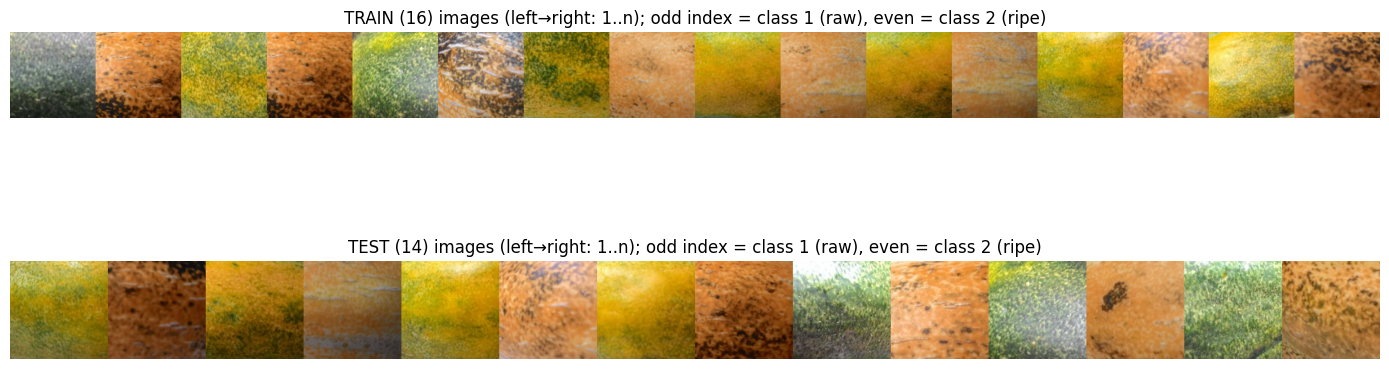

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 1, figsize=(14, 6))
def show_row(ax, files, prefix):
    grid = []
    for i, f in enumerate(files):
        img = np.asarray(PIL.Image.open(outdir / f).convert("RGB"))
        grid.append(img)
    # thumbnails at common height
    h = 120
    thumbs = []
    for img in grid:
        w = int(img.shape[1] * h / img.shape[0])
        thumbs.append(np.asarray(PIL.Image.fromarray(img).resize((w, h))))
    ax.imshow(np.hstack(thumbs))
    ax.set_title(f"{prefix} images (left→right: 1..n); odd index = class 1 (raw), even = class 2 (ripe)")
    ax.axis("off")

show_row(axes[0], train_files, "TRAIN (16)")
show_row(axes[1], test_files, "TEST (14)")
plt.tight_layout()
plt.savefig("/content/input_preview.png", dpi=110, bbox_inches="tight")
plt.show()

### Preprocessing: MATLAB → Python mapping

The paper's pipeline (Pre-Processing section, p. 2–3) is `rgb2gray → medfilt2 → adapthisteq`. This port keeps MATLAB's exact numerical conventions:

| MATLAB (`NaiveBayes.m`) | Python equivalent here | Note |
|---|---|---|
| `rgb2gray` (0.2989R+0.5870G+0.1140B, uint8) | `matlab_rgb2gray` | Rec.601 luma weights, rounded to uint8 |
| `medfilt2(b,[9 9])` (zero-padded border) | `scipy.ndimage.median_filter(size=k, mode='constant', cval=0)` | script uses 9×9 train, 3×3 test |
| `adapthisteq(c)` (8×8 tiles, clip 0.01, uint8 out) | `skimage.exposure.equalize_adapthist` → rescaled to uint8 | closest documented equivalent; small implementation differences possible |
| `imread` / `rgb2gray` | PIL + numpy | — |

**日本語:** 前処理はMATLABの係数・境界条件（ゼロパディング）・uint8出力を保つよう移植しています。`adapthisteq` は実装差が残るため、その旨を明記します。

In [ ]:
from scipy import ndimage
from skimage.exposure import equalize_adapthist

def matlab_rgb2gray(img_u8):
    """MATLAB rgb2gray: Rec.601 luma weights, rounded to uint8 (NaiveBayes.m line 8/26)."""
    w = np.array([0.2989, 0.5870, 0.1140])
    return np.round(np.tensordot(img_u8.astype(np.float64), w, axes=([2], [0]))).astype(np.uint8)

def medfilt2(img_u8, k):
    """MATLAB medfilt2 with default zero padding (NaiveBayes.m line 9/27)."""
    return ndimage.median_filter(img_u8, size=k, mode="constant", cval=0)

def adapthisteq_u8(img_u8):
    """MATLAB adapthisteq default (8x8 tiles, clip 0.01); output cast back to uint8 like MATLAB."""
    out = equalize_adapthist(img_u8, clip_limit=0.01, nbins=256)
    return np.round(out * 255.0).astype(np.uint8)

def preprocess(path_rgb, medfilt_k):
    a = np.asarray(PIL.Image.open(path_rgb).convert("RGB"))
    b = matlab_rgb2gray(a)
    c = medfilt2(b, medfilt_k)
    d = adapthisteq_u8(c)
    return a, b, d

### Preprocessed image preview

Shows the grayscale → 9×9 median-filtered → contrast-enhanced result for one training image of each class (`l1`, `l2`) and one test image (`u1`), so the learner can see what the feature extractor actually measures.

**日本語:** グレースケール化・メディアンフィルタ（9×9）・適応的ヒストグラム均一化後の画像を表示します。

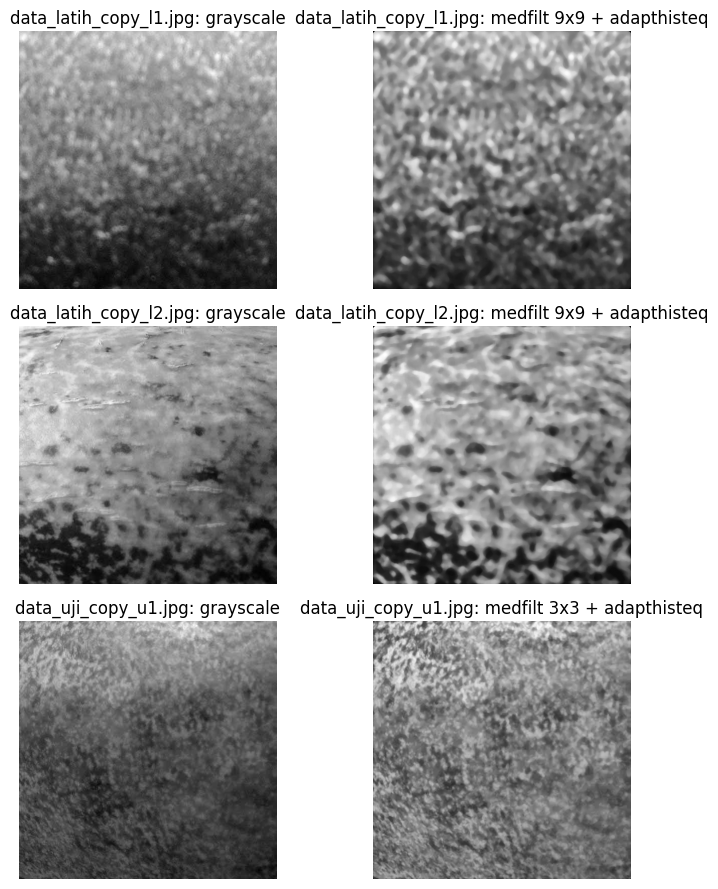

In [ ]:
fig, axes = plt.subplots(3, 2, figsize=(8, 9))
for row, (fname, kf) in enumerate([("data_latih_copy_l1.jpg", 9),
                                   ("data_latih_copy_l2.jpg", 9),
                                   ("data_uji_copy_u1.jpg", 3)]):
    a, b, d = preprocess(outdir / fname, kf)
    axes[row, 0].imshow(b, cmap="gray"); axes[row, 0].set_title(f"{fname}: grayscale")
    axes[row, 1].imshow(d, cmap="gray"); axes[row, 1].set_title(f"{fname}: medfilt {kf}x{kf} + adapthisteq")
    for ax in axes[row]: ax.axis("off")
plt.tight_layout()
plt.savefig("/content/preprocess_preview.png", dpi=110, bbox_inches="tight")
plt.show()

### Feature extraction: the paper's five histogram features

Port of `NaiveBayes.m` lines 11–16, preserving MATLAB conventions exactly:

- `mean(mean(d))` → global mean.
- `std2(d)` → **sample** standard deviation (`ddof=1`).
- `entropy(d)` → −Σ p·log₂p over the **256-bin** grayscale histogram (MATLAB `entropy` definition).
- `skewness(skewness(d1))` → MATLAB `skewness` (biased, flag=1) applied **per column** first, then to the resulting 1-D vector — an unusual but deliberate double application in the author's script; reproduced as-is.
- `kurtosis(kurtosis(d1))` → same double application; MATLAB kurtosis is **non-excess** (Fisher=False), biased.

**日本語:** 5特徴量（平均・標準偏差・エントロピー・歪度・尖度）をMATLABの規約（不偏分散、バイアスあり歪度/尖度、256階調ヒストグラム、列方向→ベクトルの二重適用）を保ったまま移植します。

In [ ]:
from scipy.stats import skew, kurtosis

def matlab_features(d_u8):
    d1 = d_u8.astype(np.float64)                       # MATLAB: d1 = double(d)
    e = d1.mean()                                       # mean(mean(d))
    f = d1.std(ddof=1)                                  # std2 (sample std)
    p = np.bincount(d_u8.ravel(), minlength=256) / d_u8.size
    p = p[p > 0]
    g = float(-(p * np.log2(p)).sum())                  # entropy, 256 bins
    h = float(skew(skew(d1, axis=0, bias=True), bias=True))   # double skewness
    i = float(kurtosis(kurtosis(d1, axis=0, bias=True), bias=True, fisher=False))
    return np.array([e, f, g, h, i])

### Extract features for all 30 images and build label vectors

Runs the script-faithful pipeline (train 9×9, test 3×3 median filter) over the whole dataset and builds the alternating label vectors from `NaiveBayes.m` lines 48–52 / 60–64 (class 1 = raw, class 2 = ripe). A small table of the first rows is displayed for inspection.

**日本語:** 30枚全ての特徴量を抽出し、スクリプトの交互ラベル（1=未成熟, 2=成熟）で学習・テスト行列を作成します。

In [ ]:
FEATS = ["mean", "std", "entropy", "skewness", "kurtosis"]

X_train = np.stack([matlab_features(preprocess(outdir / f, 9)[2]) for f in train_files])
X_test = np.stack([matlab_features(preprocess(outdir / f, 3)[2]) for f in test_files])

# alternating labels exactly as the author script builds them
y_train = np.array([1 if i % 2 == 0 else 2 for i in range(16)])
y_test = np.array([1 if i % 2 == 0 else 2 for i in range(14)])

feat_df = pd.DataFrame(X_train, columns=FEATS)
feat_df.insert(0, "sample", [f"l{i+1}" for i in range(16)])
feat_df.insert(1, "class", y_train)
print("X_train", X_train.shape, "X_test", X_test.shape)
display(feat_df.head(6).round(4))

X_train (16, 5) X_test (14, 5)


,sample,class,mean,std,entropy,skewness,kurtosis
0,l1,1,120.4439,48.0741,7.5459,-0.2323,2.1373
1,l2,2,137.3452,50.6844,7.5741,0.5846,4.0215
2,l3,1,151.6907,40.0376,7.3454,0.0302,12.4623
3,l4,2,132.6898,50.3083,7.5722,0.1504,3.1335
4,l5,1,135.3713,45.1830,7.5142,-1.8739,10.6145
5,l6,2,134.7183,57.2217,7.7877,0.1076,2.8075


### Train Gaussian Naive Bayes (paper: 68.75% training accuracy)

`sklearn.naive_bayes.GaussianNB` is the direct equivalent of MATLAB `fitcnb` with its default Gaussian kernel and empirical (8/8, equal) class priors. Predictions on the **training** set are compared with the original labels, replicating `NaiveBayes.m` lines 73–106.

**日本語:** `GaussianNB`（MATLAB `fitcnb`の既定：ガウシアン核・経験事前確率）で学習し、学習データへの予測精度を論文の 68.75%（11/16）と比較します。

In [ ]:
from sklearn.naive_bayes import GaussianNB

model = GaussianNB()
model.fit(X_train, y_train)
y_train_pred = model.predict(X_train)
train_correct = int((y_train_pred == y_train).sum())
train_acc = train_correct / 16 * 100
print(f"training: {train_correct}/16 correct = {train_acc:.2f}%  (paper: 11/16 = 68.75%)")

training: 12/16 correct = 75.00%  (paper: 11/16 = 68.75%)


### Test on the 14 held-out images (paper: 57.14% testing accuracy)

Predicts the test features with the trained model (`NaiveBayes.m` lines 109–142) and reports the overall test accuracy against the paper's 8/14 = 57.14%.

**日本語:** 学習済みモデルでテスト14枚を予測し、論文の 57.14%（8/14）と比較します。

In [ ]:
y_test_pred = model.predict(X_test)
test_correct = int((y_test_pred == y_test).sum())
test_acc = test_correct / 14 * 100
print(f"testing: {test_correct}/14 correct = {test_acc:.2f}%  (paper: 8/14 = 57.14%)")

testing: 5/14 correct = 35.71%  (paper: 8/14 = 57.14%)


### Results table and per-class breakdown

Collects the computed accuracies next to the paper's published values, plus per-class training/test correctness, and exports a small CSV inside the Colab VM. A bar chart (created for this notebook, **not** an author figure) compares computed vs published accuracies.

**日本語:** 実測精度と論文値を併記した表、クラス別の内訳、CSVエクスポート、および比較棒グラフ（本ノートブックで追加作成した図であり論文の図ではありません）を示します。

,computed_correct,computed_acc_%,paper_acc_%
training,12/16,75.00,68.75
testing,5/14,35.71,57.14


train class 1 (raw): 6/8 correct
train class 2 (ripe): 6/8 correct
test class 1 (raw): 3/7 correct
test class 2 (ripe): 2/7 correct


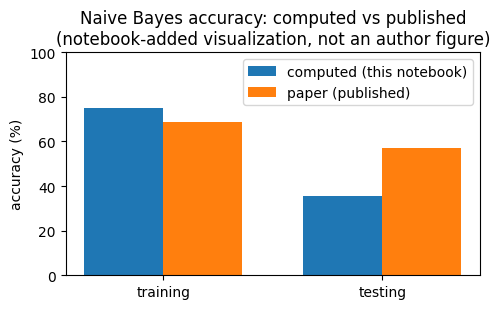

In [ ]:
results = pd.DataFrame({
    "computed_correct": [f"{train_correct}/16", f"{test_correct}/14"],
    "computed_acc_%": [round(train_acc, 2), round(test_acc, 2)],
    "paper_acc_%": [68.75, 57.14],
}, index=["training", "testing"])
display(results)
results.to_csv("/content/naive_bayes_results.csv")

for name, yt, yp in (("train", y_train, y_train_pred), ("test", y_test, y_test_pred)):
    for cls, label in ((1, "raw"), (2, "ripe")):
        m = yt == cls
        print(f"{name} class {cls} ({label}): {(yp[m] == cls).sum()}/{m.sum()} correct")

fig, ax = plt.subplots(figsize=(5, 3.2))
xpos = np.arange(2)
ax.bar(xpos - 0.18, results["computed_acc_%"], width=0.36, label="computed (this notebook)")
ax.bar(xpos + 0.18, results["paper_acc_%"], width=0.36, label="paper (published)")
ax.set_xticks(xpos, results.index); ax.set_ylabel("accuracy (%)"); ax.set_ylim(0, 100)
ax.set_title("Naive Bayes accuracy: computed vs published\n(notebook-added visualization, not an author figure)")
ax.legend()
plt.tight_layout()
plt.savefig("/content/accuracy_comparison.png", dpi=110, bbox_inches="tight")
plt.show()

### Sensitivity variant: paper-stated 9×9 median filter for test images

The paper text states a 9×9 median filter, while the author script uses 3×3 for test images. This **additional, clearly labeled variant** re-extracts test features with 9×9 to show how much this discrepancy matters. It is not part of the faithful script port.

**日本語:** 論文記載の9×9フィルタをテスト画像に適用した比較（追加の感度分析セル。スクリプトの忠実な移植ではありません）。

In [ ]:
X_test_99 = np.stack([matlab_features(preprocess(outdir / f, 9)[2]) for f in test_files])
y_pred_99 = model.predict(X_test_99)
c99 = int((y_pred_99 == y_test).sum())
print(f"testing with 9x9 median filter: {c99}/14 correct = {c99/14*100:.2f}%")

testing with 9x9 median filter: 7/14 correct = 50.00%


## Interpretation, limitations, and validation record

**What was reproduced.** The complete paper experiment on the author's own 30 images: preprocessing, the five gray-level features with MATLAB conventions, Gaussian NB training/testing, and comparison with the published 68.75% / 57.14% accuracies (see the table above for this run's measured values).

**Differences from the paper / limitations:**
- **AI-assisted translation from MATLAB R2016a** (`NaiveBayes.m` @ `10620c2`); the authors did not provide Python code. `adapthisteq` and its interaction with the median filter have small implementation differences from the MATLAB toolbox, so per-image feature values (and possibly the accuracy) may deviate slightly; the paper's published accuracies are the reference check.
- The paper text's 9×9 test filter vs the script's 3×3 is documented in the variant cell above.
- Image class order follows the author script (alternating); per-image paper tables were not machine-extractable in the prior investigation.
- Image acquisition setup (camera, lighting, distance) is undocumented; the LVQ comparison (reference [14]) is out of scope.
- The author repository has no declared license; data/code are used here only transiently inside Colab with attribution.

**日本語:** 論文の全実験（30枚・5特徴量・Gaussian NB・精度比較）を著者データで再現しました。MATLABからのAI支援翻訳のため、`adapthisteq` 等の実装差により特徴量・精度が多少変動し得ます。9×9/3×3の不一致は比較セルで確認できます。LVQ比較と撮影条件は対象外です。

**References**
1. M. F. Asy'ari et al., J. Phys.: Conf. Ser. 1805 012028 (2021). doi:10.1088/1742-6596/1805/1/012028
2. Author repository: https://github.com/falachari/tugas-akhir-naive-bayes (commit `10620c2a2fa472ef32f8712cc81cc7cbb7a2be1d`), file `NaiveBayes.m`.
3. MATLAB docs: `fitcnb`, `adapthisteq`, `medfilt2`, `entropy` (R2016a default behaviors).